# pyGAlib example: Generation weighted (random) graphs and weighted surrogates
Authors: **Gorka Zamora-López, Ph.D.** and **Matthieu Gilson, Ph.D.**

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>


<img src="Images/logo_CONECT.png" align="right" width="150" alt="logo CONECT">
<img src="Images/logo_AMU.png" align="right" width="150" alt="logo AMU">


<br>
<br>

---------------------

This notebook illustrate the capabilities of *pyGAlib* to deal with weighted graphs. In particular it will show how to:

1. add random weights to existing graphs and digraphs,
2. generate (random) weighted (di)graphs, and
3. create surrogate weighted graphs from a given one.

Functions to create both binary and weighted graphs can be found in module *models.py*. As usual, type `help(galib.models)` or `models?` in an interactive Python session to get a list of all network generation functions and, specific instructions for each generating function as `help(galib.FunctionName)` or `galib.FunctionName?`.


## Import dependencies

The Notebook requires a __*Python*__ (>=3.6) installation together with __*NumPy*__ (>1.6) and __*pyGAlib*__ (>=2.1), and __*Matplotlib*__ for the visualizations. Please make sure these packages are installed in the same environment in which this notebook is running.


In [1]:
# 1) Python standard library imports

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local libraries
import galib


## 1) Seeding random weights to (directed) graphs
To begin with, let's generate a small graph (e.g., a star graph) and add random weights to its links, drawn from random number distribution of choice. For that, we will use function `galib.SeedRandomWeights()`. The function accepts: 

1. Two mandatory positional parameters:
    - `adjmatrix` corresponding the (di)graph to which weights will be added, and
    - `w_dist` the random number generator function, e.g., from *NumPy* or the *SciPy* packages.
2. Various optional parameters. We will see them later.
3. Keyword arguments (`**arg_w_distr`) usually related to the random number generator `w_dist`. 

> NOTE: In *pyGAlib* functions to generate binary (di)graphs return 2D *ndarrays* of `np.uint8` dtype. Adding random weights, or generating a new (randomly) weigthed graph returns them in `np.float64` dtype.

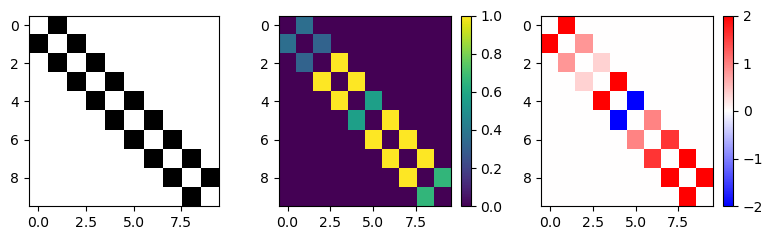

In [2]:
# Create a small graph
N = 10
#net = galib.StarGraph(N)
net = galib.PathGraph(N)

# Create two weigthed versions, seeding weights from a uniform and a normal distributions.
# Parameters of the random number generator are passed as keyword arguments. 
# For the uniform distribution (between 0 and 1) these will be `low = 0` and `high = 1`
wnet1 = galib.SeedRandomWeights(net, np.random.uniform,  low=0, high=2)
# For the normal distribution these will be `loc=0` and `scale=2`.
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  loc=0, scale=2)

# Visualize the generated matrices
plt.figure(figsize=(8,2.5))
plt.subplot(1,3,1)
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wnet1, aspect='auto')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(wnet2, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


In [3]:
# Print some feedback ...
print( f"Are the networks directed?  net: {galib.is_directed(net)}  wnet1: {galib.is_directed(wnet1)}  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are the weights symmetric?  net: {galib.is_symmetric(net)}  wnet1: {galib.is_symmetric(wnet1)}  wnet2: {galib.is_symmetric(wnet2)}" )
#

Are the networks directed?  net: False  wnet1: False  wnet2: False
Are the weights symmetric?  net: True  wnet1: True  wnet2: True


As seen, the weights were seeded symmetrically such that $w_{ij} = w_{ji}$. This is because `SeedRandomWeights()` identifies whether the input adjacency matrix represents a directed or and undirected graph and behaves accordingly.

- If the input `adjmatrix` is undirected, then it will seed weights symmetrically.
- Instead, if the input `adjmatrix` is a directed graph, it will seed weigths non-symmetrically.

However, this behaviour can be controlled using optional parameter `sym_w`. By default `sym_w = None`, which makes the function to first check the directedness of the input matrix `adjmatrix` and behave accordingly. But, setting `sym_w = False` the weights will be randomly assigned ignoring whether the input matrix is an undirected graph or not, and returning an asymmetric connectivity matrix such that $w_{ij} \neq w_{ji}$, in general.

Let's now seed the weights to `net` using `sym_w = False`.

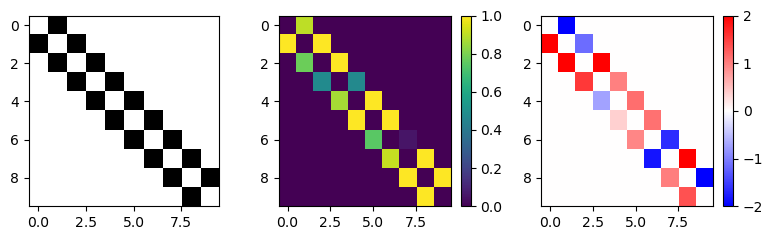

In [4]:
# Set optional parameter sym_w = False
wnet1 = galib.SeedRandomWeights(net, np.random.uniform, sym_w=False,  low=0, high=2)
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  sym_w=False,  loc=0, scale=2)

# Visualize the generated matrices
plt.figure(figsize=(8,2.5))
plt.subplot(1,3,1)
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wnet1, aspect='auto')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(wnet2, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()

In [5]:
# Print some feedback ...
print( f"Are the networks directed?  net: {galib.is_directed(net)}  wnet1: {galib.is_directed(wnet1)}  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are the weights symmetric?  net: {galib.is_symmetric(net)}  wnet1: {galib.is_symmetric(wnet1)}  wnet2: {galib.is_symmetric(wnet2)}" )
#

Are the networks directed?  net: False  wnet1: False  wnet2: False
Are the weights symmetric?  net: True  wnet1: False  wnet2: False


CONTINUE HERE !! *Show examples for a digraph, that gets asymmetric weights by default but can be forced to have a symmetric and an asymmetric component*

- when `sym_w = True` the function forces all reciprocal links ($A_{ij} = A_{ji} = 1$) to have the same weight such that $w_{ij} = w_{ji}$. This implies that, if `adjmatrix` is a undirected, then all weights are symmetric and, if `adjmatrix` is directed, then all reciprocal links receive the same weight, leading to ... FINISH THIS
